<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# Chapter 4: Implementing a GPT model from Scratch To Generate Text 

In [37]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.8
torch version: 2.10.0
tiktoken version: 0.12.0


本章我们将实现一个类似GPT的LLM架构

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/01.webp" width="900px">

## 4.1 编写LLM架构代码

第一章讨论了GPT和Llama等模型，它们按顺序生成单词，并且基于原始Transformer架构的解码器部分。因此，这些LLM通常被称为“解码器式”LLM。   
与传统的深度学习模型相比，LLM 的规模更大，这主要是由于其参数数量庞大，而非代码量更大。我们将看到，LLM架构中有很多元素是重复出现的。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/02.webp" width="600px">

在前几章中，为了便于说明，我们使用了较小的词元输入和输出嵌入维度，以确保它们能够显示在一页纸上。本章中，我们将考虑类似于小型 GPT-2 模型的嵌入和模型规模。   
我们将具体编写最小的 GPT-2 模型（1.24 亿个参数）的架构代码 [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)       
第 6 章将展示如何将预训练权重加载到我们的实现中，该实现将兼容 3.45 亿、7.62 亿和 15.42 亿参数的模型规模。

In [38]:
# 1.24亿参数GPT-2模型的配置详情
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 这表明词汇量为 50,257 个词，该结果由第二章讨论的 BPE 分词器支持。
    "context_length": 1024, # 表示模型的最大输入词元数，这是通过第2章中介绍的位置嵌入确定的。
    "emb_dim": 768,         # 是词元输入的嵌入大小，将每个输入词元转换为一个 768 维向量。
    "n_heads": 12,          # 是第三章中实现的多头注意力机制中的注意力头数量。
    "n_layers": 12,         # 是模型中 Transformer 模块的数量，我们将在后续章节中实现它。
    "drop_rate": 0.1,       # 是dropout机制的强度，在第3章中讨论；0.1 表示在训练过程中丢弃 10% 的隐藏单元，以减轻过拟合。
    "qkv_bias": False       # 决定多头注意力机制（第 3 章）中的“线性”层在计算查询 (Q)、键 (K) 和值 (V) 张量时是否应包含偏置向量；
                            # 我们将禁用此选项，这是现代线性模型中的标准做法；但是，我们将在第 5 章将 OpenAI 的预训练 GPT-2 权重加载到我们的重新实现中时再讨论这个问题。
}

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="800px">

In [39]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/04.webp?123" width="500px">

In [40]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [41]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


---

**Note**

- 如果您在 Windows 或 Linux 系统上运行此代码，则上述结果值可能如下所示。:
    
```
Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)
```

- 由于这些只是随机数字，所以无需关心，您可以继续阅读本章剩余部分，不会有任何问题。
- 造成这种差异的一个可能原因是，正如之前讨论过的，`nn.Dropout` 在不同操作系统上的行为有所不同，这取决于 PyTorch 的编译方式。[here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

---

## 4.2 使用层归一化对激活值进行归一化

- 层归一化，也称为 LayerNorm ([Ba et al. 2016](https://arxiv.org/abs/1607.06450)), 将神经网络层的激活值集中在均值为0的位置，并将其方差归一化为1。(稳定每一层输入的分布，解决深度网络训练的核心痛点，从根本上提升训练稳定性、收敛速度与最终模型性能。)。
- 这有助于稳定训练，并能更快地达到有效权重
- 在Transformer模块中，多头注意力模块（我们稍后会实现）前后都会应用层归一化；此外，最终输出层之前也会应用层归一化。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="800px">

让我们通过将一个小的输入样本输入到一个简单的神经网络层中来了解层归一化是如何工作的。

In [42]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [43]:
# 让我们计算以上两个输入的均值和方差。
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


归一化分别应用于两个输入（行）中的每一个；使用 dim=-1 会将计算应用于最后一个维度（在本例中为特征维度），而不是行维度

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/06.webp" width="400px">

In [44]:
# 减去均值并除以方差（标准差）的平方根，即可将输入值中心化，使其在列（特征）维度上的均值为 0，方差为 1。
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [45]:
# 每个输入均以 0 为中心，方差为 1；为了提高可读性，我们可以禁用 PyTorch 的科学计数法
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


上面，我们对每个输入的特征进行了归一化处理。   
现在，运用同样的思路，我们可以实现一个 `LayerNorm` 类：

In [46]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**缩放和偏移**

- 请注意，除了通过减去均值并除以方差进行归一化之外，我们还添加了两个可训练参数，即“缩放”参数和“偏移”参数。
- 初始的“缩放”（乘以 1）和“偏移”（加 0）值没有任何影响；但是，“缩放”和“偏移”是可训练参数，LLM 会在训练过程中自动调整它们，前提是确定这样做可以提高模型在训练任务上的性能。
- 这使得模型能够学习最适合其处理数据的适当缩放和平移方法
- 请注意，在计算方差的平方根之前，我们还会加上一个较小的值（`eps`）；这是为了避免方差为 0 时出现除以零的错误。

**有偏方差**
- 在上述方差计算中，设置 `unbiased=False` 意味着使用公式 $\frac{\sum_i (x_i - \bar{x})^2}{n}$ 计算方差，其中 n 为样本大小（此处为特征或列数）；该公式未包含贝塞尔校正（分母使用 `n-1`），因此提供的方差估计是有偏的。
- 对于嵌入维度“n”非常大的LLM模型，使用“n”和“n-1”之间的差异可以忽略不计。
- 然而，GPT-2 在归一化层中使用了有偏方差进行训练，因此出于与预训练权重（我们将在后续章节中加载）的兼容性考虑，我们也采用了这种设置。

- 现在让我们实际尝试一下 `LayerNorm`

In [47]:
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

In [48]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


> 方差不正好是 1，因为我们使用的是 `eps`

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/07.webp" width="600px">

## 4.3 实现具有GELU激活的前馈网络

- 在本节中，我们实现一个小型神经网络子模块，该子模块用作 LLM 中 Transformer 模块的一部分。
- 我们首先来看激活函数
- 在深度学习中，ReLU（修正线性单元）激活函数因其简单性和在各种神经网络架构中的有效性而被广泛使用。
- 在 LLM 中，除了传统的 ReLU 之外，还使用了各种其他类型的激活函数；两个值得注意的例子是 GELU（高斯误差线性单元）和 SwiGLU（Swish 门控线性单元）
- GELU 和 SwiGLU 是更复杂、更平滑的激活函数，分别融合了高斯门控单元和 Sigmoid 门控单元，与 ReLU 这种更简单的分段线性函数相比，它们能为深度学习模型提供更好的性能。

- GELU ([Hendrycks 和 Gimpel 2016](https://arxiv.org/abs/1606.08415)) 可以用多种方式实现；精确版本定义为 GELU(x)=x⋅Φ(x)，其中 Φ(x) 是标准高斯分布的累积分布函数。
- 在实践中，通常会采用计算成本更低的近似方法: $\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$ (原始的GPT-2模型也是用这种近似方法训练的)

In [49]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

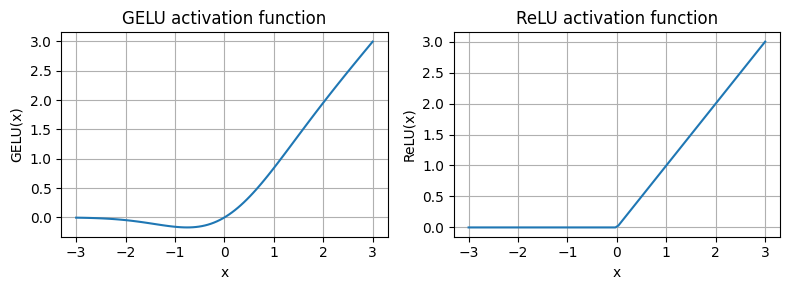

In [50]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- 如我们所见，ReLU 是一个分段线性函数，当输入为正时直接输出；否则输出零
- GELU 是一个平滑的非线性函数，它近似于 ReLU，但对于负值具有非零梯度（约 -0.75 处除外）。

In [51]:
# 接下来，我们来实现小型神经网络模块 `FeedForward`，稍后我们将在 LLM 的 transformer 模块中使用它：
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [52]:
print(GPT_CONFIG_124M["emb_dim"])

768


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/09.webp?12" width="400px">

In [53]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/10.webp" width="800px">

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/11.webp" width="800px">

## 4.4 添加快捷连接

- 接下来，我们来谈谈快捷连接（也称为跳跃连接或剩余连接）背后的概念。
- 最初，在计算机视觉的深度网络（残差网络）中提出快捷连接是为了缓解梯度消失问题。
- 捷径连接为梯度在网络中流动提供了一条更短的替代路径。
- 这是通过将一层的输出添加到后面一层的输出来实现的，通常会跳过中间的一层或多层。
- 让我们用一个简单的网络示例来说明这个概念：

> x = x + layer_output 虽然在前向传播时只是简单的相加，但在反向传播时，它为梯度提供了一条 “绿色通道”。即使中间的非线性变换层（layer）的梯度很小，梯度也能通过这个加法操作畅通无阻地回传到更早的层，从而有效地缓解了梯度消失问题。
>    
> 快捷连接的作用是 **“保活”（保证梯度不为 0，网络能训下去），而不是“替代”**（替代梯度计算，让网络变聪明）。
>  - 那个 “+1” 解决了 **“能不能训”** 的问题。
>  - 那个 “f′(x)” 解决了 **“能不能变好”** 的问题。
>    
> 两者缺一不可。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/12.webp?123" width="800px">

In [60]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [61]:
# 我们先在不连接快捷方式的情况下打印渐变值。
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [62]:
# 接下来，我们用快捷连接打印渐变值
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


- 从上面的输出可以看出，快捷连接可以防止梯度在早期层（向第 0 层）消失。
- 接下来，我们在实现 Transformer 模块时会用到这种快捷连接的概念。

## 4.5 在 Transformer 模块中连接注意力层和线性层

- 在本节中，我们将前面的概念组合成一个所谓的转换器模块
- Transformer模块将上一章的因果多头注意力模块与我们在前面章节中实现的线性层和前馈神经网络相结合
- 此外，transformer模块还采用了dropout和shortcut连接。

In [63]:
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch03 import MultiHeadAttention

from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/13.webp?1" width="600px">

- 假设我们有两个输入样本，每个样本包含 4 个 token，其中每个 token 都是一个 768 维的嵌入向量；那么这个 Transformer 模块会应用自注意力机制，然后接上线性层，最终生成一个大小类似的输出。
- 你可以把输出看作是我们在上一章讨论的上下文向量的增强版本。

In [64]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/14.webp?1" width="600px">

## 4.6 实现GPT模型

- 我们快要完成了：现在让我们把Transformer模块接入到本章开头编写的架构中，从而得到一个可用的GPT架构
- 请注意，transformer模块重复使用了多次；对于最小的124M GPT-2模型，我们重复使用了 12 次：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/15.webp" width="600px">

- 相应的代码实现，其中 `cfg["n_layers"] = 12`

In [65]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [66]:
# 利用 124M 参数模型的配置，我们现在可以按如下方式使用随机初始权重实例化此 GPT 模型：
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


- 我们将在下一章训练这个模型

In [70]:
# 不过，关于它的大小需要快速说明一下：我们之前称其为 1.24 亿参数模型；我们可以通过以下方式再次确认这个数字
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


- 如上所示，该模型有 1.63 亿个参数，而不是 1.24 亿个；为什么？
- 在最初的 GPT-2 论文中，研究人员采用了权重绑定，这意味着他们将词嵌入层（`tok_emb`）重用为输出层，也就是设置 `self.out_head.weight = self.tok_emb.weight`。
- token嵌入层将50,257维输入token的one-hot编码投影到768维的embedding表示中
- 输出层将768维的embedding投影回到50,257维的表示中，以便我们可以将其转换回单词（更多关于此的信息请参见下一节）
- 因此，嵌入层和输出层具有相同数量的权重参数，我们可以从它们的权重矩阵的形状看出这一点。
- 不过，关于它的大小，需要快速说明一下：我们之前称其为 1.24 亿参数模型；我们可以通过以下方式再次确认这个数字:

In [71]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


- 在最初的 GPT-2 论文中，研究人员将词嵌入矩阵重用为输出矩阵。
- 相应地，如果我们减去输出层的参数数量，就会得到一个 1.24 亿参数的模型:

In [72]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- 实际上，我发现不进行权重绑定更容易训练模型，所以我们在这里没有实现权重绑定。
- 不过，我们将在第5章加载预训练权重时再次讨论并应用这种权重绑定方法。
- 最后，我们可以按如下方式计算模型的内存需求，这可以作为一个有用的参考点

In [73]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


- 练习：你可以尝试实现以下其他配置，这些配置也在 [GPT-2 paper](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C) 中提到.

    - **GPT2-small** (我们已经实现的124M参数配置):
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium:**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large:**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL:**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

## 4.7 生成文本

像我们上面实现的GPT模型这样的语言学习模型（LLM）一次生成一个词

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="400px">

- 以下的 `generate_text_simple` 函数实现了贪婪解码，这是一种简单快速的文本生成方法。
- 在贪婪解码中，模型在每一步都选择概率最高的单词（或 token）作为其下一个输出（最高的 logits 输出对应于最高的概率，所以我们甚至不需要显式地计算 softmax 函数）
- 在下一章中，我们将实现一个更高级的 generate_text 函数
- 下图展示了 GPT 模型如何根据给定的输入上下文生成下一个词元

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="800px">

In [74]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx 是当前上下文中的索引数组（batch，n_tokens）
    for _ in range(max_new_tokens):
        
        # 如果当前上下文超过了支持的长度，就对当前上下文进行截断
        # 例如，如果LLM只支持5个token，而上下文长度为10，
        # 那么只有最后5个token会被用作上下文

        idx_cond = idx[:, -context_size:]
        
        # 获取预测结果
        with torch.no_grad():
            logits = model(idx_cond)
        
        # 只关注最后一个时间步
        # (batch, n_token, vocab_size)变为(batch, vocab_size)
        logits = logits[:, -1, :]  

        # 通过softmax函数获得对应的概率
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # 获取概率值最高的单词索引
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 将采样到的索引添加到当前运行的上下文索引序列中
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

- 上面的 generate_text_simple 函数实现了一个迭代过程，每次创建一个 token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/18.webp" width="600px">

- 让我们准备一个输入示例:

In [75]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [76]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


- 移除批次维度并转换回文本:

In [77]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


- 请注意，该模型未经训练；因此以上输出文本是随机的。
- 我们将在下一章训练这个模型

&nbsp;
## Summary and takeaways

- See the [./gpt.py](./gpt.py) script, a self-contained script containing the GPT model we implement in this Jupyter notebook
- You can find the exercise solutions in [./exercise-solutions.ipynb](./exercise-solutions.ipynb)